In [ ]:
import pandas as pd

df =pd.read_excel('Online Retail.xlsx')

       InvoiceNo StockCode                         Description  Quantity  \
138262    548192     84465        15 PINK FLUFFY CHICKS IN BOX         1   
35044     539434     22492             MINI PAINT SET VINTAGE          1   
117744    546406     20972  PINK CREAM FELT CRAFT TRINKET BOX          1   
301184    563245     21670       BLUE SPOT CERAMIC DRAWER KNOB        18   
66884     541827    84520B  PACK 20 ENGLISH ROSE PAPER NAPKINS         1   

               InvoiceDate  UnitPrice  CustomerID         Country  
138262 2011-03-29 15:22:00       2.95     17364.0  United Kingdom  
35044  2010-12-17 14:41:00       1.66         NaN  United Kingdom  
117744 2011-03-11 16:21:00       2.46         NaN  United Kingdom  
301184 2011-08-15 10:53:00       1.25     16272.0  United Kingdom  
66884  2011-01-21 17:05:00       1.63         NaN  United Kingdom  


In [5]:
df.dropna(inplace=True)

In [11]:
df.drop_duplicates(inplace=True)

            Quantity  TotalAmount  Cluster
CustomerID                                
12346.0        74215     77183.60        2
12347.0         2458      4310.00        0
12348.0         2341      1797.24        0
12349.0          631      1757.55        0
12350.0          197       334.40        0


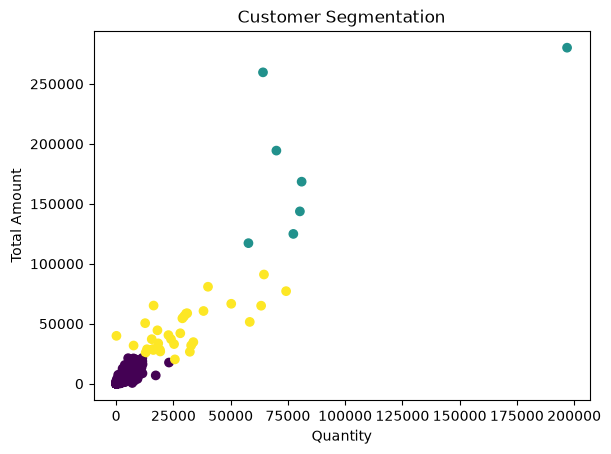

In [16]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = df.dropna(subset=["CustomerID"])

# Create total amount
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Create customer data
customer = df.groupby("CustomerID")[["Quantity", "TotalAmount"]].sum()

# Create clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer["Cluster"] = kmeans.fit_predict(customer)

# Show clusters
print(customer.head())

# Visualize
plt.scatter(
    customer["Quantity"],
    customer["TotalAmount"],
    c=customer["Cluster"]
)

plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.title("Customer Segmentation")
plt.show()